# TRAS - C70 Quenched

### Mounting the google drive

In [1]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np
import pandas as pd

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from math import pi

In [2]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# # A good test to do is if you can see the contents of the directory in which you work on your google drive.
# # Here "My Drive" refers to the "root" of your google drive.
# # By default your notebook should be in a directory called Colab Notebooks.
# # This template assumes all files you want to read in are copied in the
# # same directory. Note the slash at the end of the first line.

# #==============================================================================================================
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
pathTRAS = rootpathdrive+'/'+'My Drive/Colab Notebooks/TRAS/Pulse_width_experiments/BZ08 probemaxx pumpchange' #Sara's directory
# #==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathTRAS):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.


['pump 0 probe maxx 6 2026-03-10 12-01-21 TA.csv', 'pump 0 probe maxx 6 2026-03-10 12-01-21 TA.xml', 'pump 1 probe maxx 6 2026-03-10 12-03-43 TA.xml', 'pump 1 probe maxx 6 2026-03-10 12-03-43 TA.csv', 'pump 2 probe maxx 6 2026-03-10 12-05-49 TA.csv', 'pump 2 probe maxx 6 2026-03-10 12-05-49 TA.xml', 'pump 3 probe maxx 6 2026-03-10 12-07-54 TA.csv', 'pump 3 probe maxx 6 2026-03-10 12-07-54 TA.xml', 'pump 4 probe maxx 6 2026-03-10 12-10-06 TA.csv', 'pump 4 probe maxx 6 2026-03-10 12-10-06 TA.xml', 'pump 5 probe maxx 6 2026-03-10 12-12-03 TA.csv', 'pump 5 probe maxx 6 2026-03-10 12-12-03 TA.xml', 'pump 6 probe maxx 6 2026-03-10 12-14-13 TA.xml', 'pump 6 probe maxx 6 2026-03-10 12-14-13 TA.csv', 'pump 7 probe maxx 6 2026-03-10 12-16-08 TA.csv', 'pump 7 probe maxx 6 2026-03-10 12-16-08 TA.xml', 'pump 8 probe maxx 6 2026-03-10 12-18-07 TA.csv', 'pump 8 probe maxx 6 2026-03-10 12-18-07 TA.xml', 'pump 9 probe maxx 6 2026-03-10 12-20-32 TA.xml', 'pump 9 probe maxx 6 2026-03-10 12-20-32 TA.csv',

## Part 5 - Pulse width using ZnTPP samples

**Keeping concentration and repetition rate constant, investigate the effect of varying the
pulse width of the pump and probe lasers on the structure of the TA curve.
Plotted length of spike against increment**

Slope:     0.7797 ± 0.0098
Intercept: 0.7459 ± 0.0763
Chi²:          6.8304
DOF:           14
Reduced Chi²:  0.4879


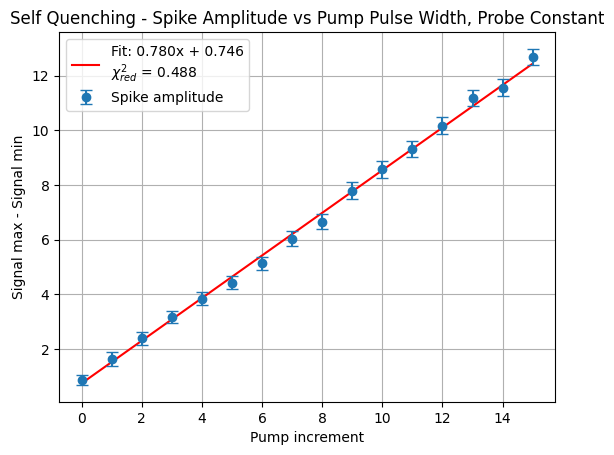

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

signal_max_array = []
signal_min_array = []
increment_array  = []
spike_array      = []
error            = []

for file in filelist:
    if not file.endswith(".csv"):
        continue
    if "TA" not in file:
        continue

    csv_title = file

    match = re.search(r"pump\s*(\d+)", csv_title)
    if not match:
        print(f"Skipping bad filename: {csv_title}")
        continue

    increment = int(match.group(1))

    df = pd.read_csv(
        os.path.join(pathTRAS, csv_title),
        sep=";",
        header=None,
        names=["time", "signal"]
    )

    df = df.iloc[1:].reset_index(drop=True)
    df = df.astype(float)
    signal = df["signal"].to_numpy()

    df_bg     = df[df["time"] < -10]
    bg_signal = df_bg["signal"].to_numpy()

    signal_min   = np.mean(bg_signal)
    signal_max   = np.max(signal)
    signal_error = np.std(bg_signal)          # Fixed: was np.stdev

    error.append(signal_error)
    signal_max_array.append(signal_max)
    signal_min_array.append(signal_min)

    spike_length = signal_max - signal_min
    spike_array.append(spike_length)
    increment_array.append(increment)

if len(increment_array) == 0:
    raise ValueError("No valid files processed — check filename pattern.")

# ── Sort (all three arrays together) ──────────────────────────────────────────
data = sorted(zip(increment_array, spike_array, error))  # Fixed: error now sorted too
increment_array, spike_array, error = zip(*data)

increment_array = np.array(increment_array, dtype=float)
spike_array     = np.array(spike_array,     dtype=float)
error           = np.array(error,           dtype=float)

# ── Weighted linear fit ────────────────────────────────────────────────────────
weights       = 1 / error
coeff, cov    = np.polyfit(increment_array, spike_array, 1, w=weights, cov=True)
slope         = coeff[0]
intercept     = coeff[1]
slope_err     = np.sqrt(cov[0, 0])
intercept_err = np.sqrt(cov[1, 1])

print(f"Slope:     {slope:.4f} ± {slope_err:.4f}")
print(f"Intercept: {intercept:.4f} ± {intercept_err:.4f}")

# ── Chi-squared ────────────────────────────────────────────────────────────────
y_pred    = slope * increment_array + intercept
residuals = spike_array - y_pred
chi2      = np.sum((residuals / error) ** 2)
dof       = len(spike_array) - 2          # 2 free parameters (slope, intercept)
chi2_red  = chi2 / dof

print(f"Chi²:          {chi2:.4f}")
print(f"DOF:           {dof}")
print(f"Reduced Chi²:  {chi2_red:.4f}")

# ── Plot ───────────────────────────────────────────────────────────────────────
x_fit = np.linspace(increment_array.min(), increment_array.max(), 200)
y_fit = slope * x_fit + intercept

plt.errorbar(increment_array, spike_array, yerr=error,        # errorbars
             fmt='o', capsize=4, label="Spike amplitude", zorder=3)
plt.plot(x_fit, y_fit, 'r-',
         label=f"Fit: {slope:.3f}x + {intercept:.3f}\n$\\chi^2_{{red}}$ = {chi2_red:.3f}")

plt.xlabel("Pump increment")
plt.ylabel("Signal max - Signal min")
plt.title("Self Quenching - Spike Amplitude vs Pump Pulse Width, Probe Constant")
plt.legend()
plt.grid(True)
plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/TRAS/Pulse_width_experiments/Self_ProbeMaxx_PumpChange.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

Slope:     774.2923 ± 19.2537
Intercept: 116.4636 ± 169.4980
Chi²:          586.9860
DOF:           14
Reduced Chi²:  41.9276


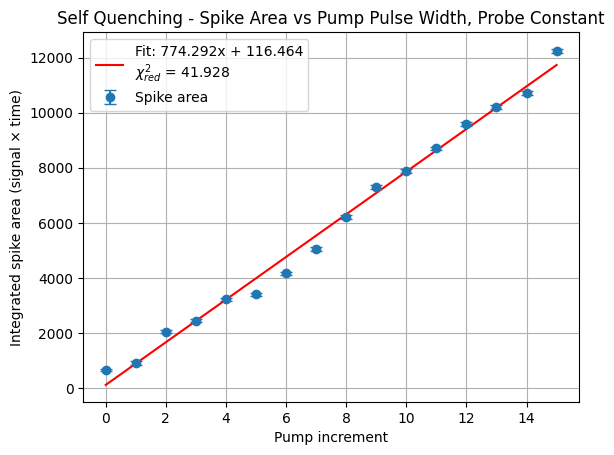

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

area_array      = []
increment_array = []
error           = []

for file in filelist:
    if not file.endswith(".csv"):
        continue
    if "TA" not in file:
        continue

    csv_title = file

    match = re.search(r"pump\s*(\d+)", csv_title)
    if not match:
        print(f"Skipping bad filename: {csv_title}")
        continue

    increment = int(match.group(1))

    df = pd.read_csv(
        os.path.join(pathTRAS, csv_title),
        sep=";",
        header=None,
        names=["time", "signal"]
    )

    df = df.iloc[1:].reset_index(drop=True)
    df = df.astype(float)

    # ── Background: pre-pump region ────────────────────────────────────────────
    df_bg     = df[df["time"] < -10]
    bg_mean   = df_bg["signal"].mean()
    bg_std    = df_bg["signal"].std()

    # ── Spike region: post-pump, background-subtracted ─────────────────────────
    df_spike  = df[df["time"] >= -10].copy()
    df_spike["signal_corr"] = df_spike["signal"] - bg_mean

    time_spike   = df_spike["time"].to_numpy()
    signal_corr  = df_spike["signal_corr"].to_numpy()

    # Trapezoidal integration of the background-subtracted spike
    spike_area = np.trapezoid(signal_corr, x=time_spike)

    # Error: bg_std * sqrt(N) * mean_dt  (propagated through sum ≈ integral)
    n_points     = len(time_spike)
    mean_dt      = (time_spike[-1] - time_spike[0]) / (n_points - 1) if n_points > 1 else 1.0
    area_error   = bg_std * np.sqrt(n_points) * mean_dt

    area_array.append(spike_area)
    increment_array.append(increment)
    error.append(area_error)

if len(increment_array) == 0:
    raise ValueError("No valid files processed — check filename pattern.")

# ── Sort ───────────────────────────────────────────────────────────────────────
data = sorted(zip(increment_array, area_array, error))
increment_array, area_array, error = zip(*data)

increment_array = np.array(increment_array, dtype=float)
area_array      = np.array(area_array,      dtype=float)
error           = np.array(error,           dtype=float)

# ── Weighted linear fit ────────────────────────────────────────────────────────
weights       = None
coeff, cov    = np.polyfit(increment_array, area_array, 1, w=weights, cov=True)
slope         = coeff[0]
intercept     = coeff[1]
slope_err     = np.sqrt(cov[0, 0])
intercept_err = np.sqrt(cov[1, 1])

print(f"Slope:     {slope:.4f} ± {slope_err:.4f}")
print(f"Intercept: {intercept:.4f} ± {intercept_err:.4f}")

# ── Chi-squared ────────────────────────────────────────────────────────────────
y_pred    = slope * increment_array + intercept
residuals = area_array - y_pred
chi2      = np.sum((residuals / error) ** 2)
dof       = len(area_array) - 2
chi2_red  = chi2 / dof

print(f"Chi²:          {chi2:.4f}")
print(f"DOF:           {dof}")
print(f"Reduced Chi²:  {chi2_red:.4f}")

# ── Plot ───────────────────────────────────────────────────────────────────────
x_fit = np.linspace(increment_array.min(), increment_array.max(), 200)
y_fit = slope * x_fit + intercept

plt.errorbar(increment_array, area_array, yerr=error,
             fmt='o', capsize=4, label="Spike area", zorder=3)
plt.plot(x_fit, y_fit, 'r-',
         label=f"Fit: {slope:.3f}x + {intercept:.3f}\n$\\chi^2_{{red}}$ = {chi2_red:.3f}")

plt.xlabel("Pump increment")
plt.ylabel("Integrated spike area (signal × time)")
plt.title("Self Quenching - Spike Area vs Pump Pulse Width, Probe Constant")
plt.legend()
plt.grid(True)
plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/TRAS/Pulse_width_experiments/Self_ProbeMaxx_PumpChange.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

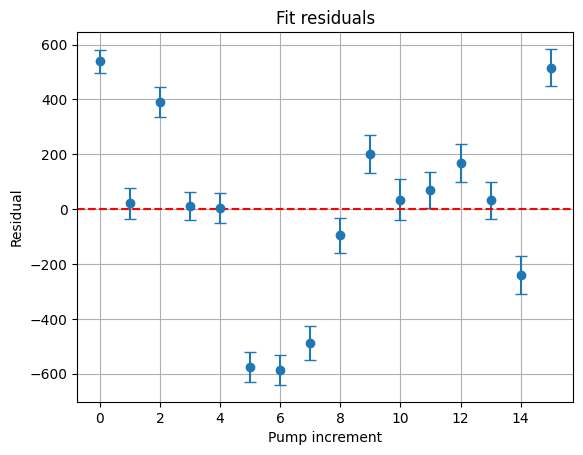

In [8]:
plt.figure()
plt.errorbar(increment_array, residuals, yerr=error, fmt='o', capsize=4)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Pump increment")
plt.ylabel("Residual")
plt.title("Fit residuals")
plt.grid(True)
plt.show()

Increment   0: A = 4.8168 ± 885622.6726,  τ = 1011.4648 ± 116.4228,  σ_IRF = 22.80 ns
Increment   1: A = 31.1404 ± 217858.1184,  τ = 760.2725 ± 42.1510,  σ_IRF = 26.18 ns
Increment   2: A = 39.6829 ± 1324290.8615,  τ = 962.0562 ± 39.8046,  σ_IRF = 31.40 ns
Increment   3: A = 40.7479 ± 296481.9630,  τ = 896.2826 ± 26.2640,  σ_IRF = 37.69 ns
Increment   4: A = 43.7860 ± 738757.9977,  τ = 909.7469 ± 25.3328,  σ_IRF = 44.60 ns
Increment   5: A = 90.6013 ± 2716389.3084,  τ = 939.5323 ± 24.9667,  σ_IRF = 51.89 ns
Increment   6: A = 69.0478 ± 622818.3759,  τ = 958.7475 ± 25.0675,  σ_IRF = 59.42 ns
Increment   7: A = 74.2437 ± 469295.8661,  τ = 972.3967 ± 24.4212,  σ_IRF = 67.11 ns
Increment   8: A = 79.1443 ± 1006907.9333,  τ = 1027.1947 ± 25.5834,  σ_IRF = 74.90 ns
Increment   9: A = 70.8948 ± 138917.7300,  τ = 1052.9172 ± 26.4714,  σ_IRF = 82.78 ns
Increment  10: A = 77.1452 ± 415073.6534,  τ = 1041.7244 ± 28.3611,  σ_IRF = 90.71 ns
Increment  11: A = 52.6446 ± 2973172.1214,  τ = 1104.8180 

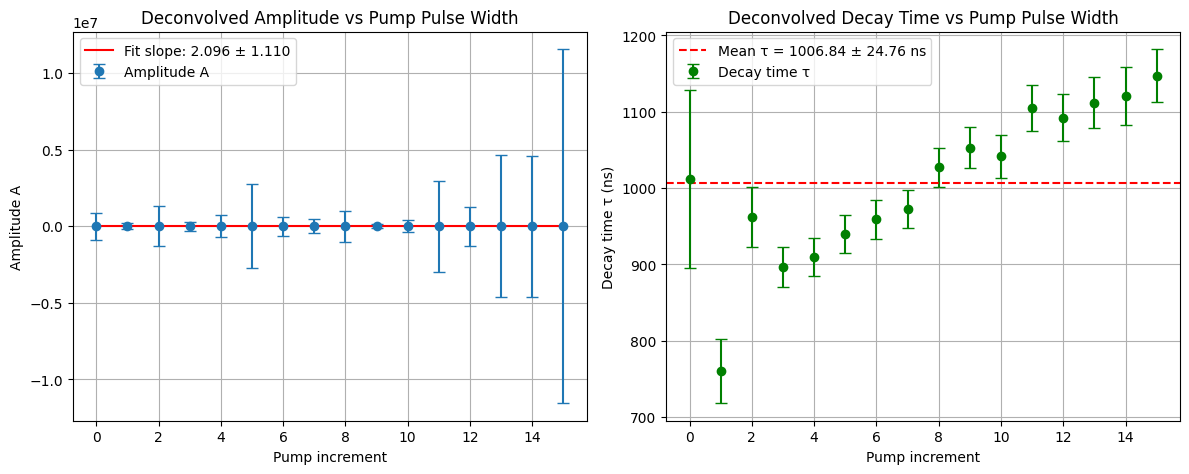

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.signal import fftconvolve
from scipy.optimize import curve_fit

# ── IRF parameters ─────────────────────────────────────────────────────────────
NS_PER_INCREMENT = (129 - 6) / 15   # ~8.2 ns per pump increment
SIGMA_PROBE      = 22.0             # midpoint of 5–39 ns probe pulse width

def model_convolved(t, A, tau, t0, sigma_irf):
    """
    Instantaneous-rise exponential decay convolved with a Gaussian IRF.
    R(t) = A * exp(-(t - t0) / tau)  for t >= t0, else 0.
    """
    dt    = t[1] - t[0]
    model = np.zeros_like(t)
    model[t >= t0] = A * np.exp(-(t[t >= t0] - t0) / tau)
    irf   = np.exp(-0.5 * (t / sigma_irf) ** 2)
    irf  /= irf.sum() * dt
    return fftconvolve(model, irf, mode='same') * dt

increment_array = []
A_array         = []
tau_array       = []
A_err_array     = []
tau_err_array   = []

for file in filelist:
    if not file.endswith(".csv"):
        continue
    if "TA" not in file:
        continue

    match = re.search(r"pump\s*(\d+)", file)
    if not match:
        print(f"Skipping bad filename: {file}")
        continue

    increment = int(match.group(1))

    df = pd.read_csv(
        os.path.join(pathTRAS, file),
        sep=";",
        header=None,
        names=["time", "signal"]
    )
    df = df.iloc[1:].reset_index(drop=True).astype(float)

    # ── Background subtraction ─────────────────────────────────────────────────
    bg_mean = df[df["time"] < -10]["signal"].mean()
    df_spike = df[df["time"] >= -10].copy()
    df_spike["signal_corr"] = df_spike["signal"] - bg_mean

    time_spike  = df_spike["time"].to_numpy()
    signal_corr = df_spike["signal_corr"].to_numpy()

    # ── Fixed IRF width from known pulse durations ─────────────────────────────
    sigma_pump  = 6.0 + increment * NS_PER_INCREMENT
    sigma_irf   = np.sqrt(sigma_pump**2 + SIGMA_PROBE**2)

    # ── Model with fixed IRF ───────────────────────────────────────────────────
    def model_fixed_irf(t, A, tau, t0):
        return model_convolved(t, A, tau, t0, sigma_irf)

    # ── Initial guesses ────────────────────────────────────────────────────────
    A_guess   = signal_corr.max()
    tau_guess = (time_spike[-1] - time_spike[0]) / 4
    t0_guess  = time_spike[np.argmax(signal_corr)]

    try:
        popt, pcov = curve_fit(
            model_fixed_irf, time_spike, signal_corr,
            p0=[A_guess, tau_guess, t0_guess],
            bounds=([0,      0.01,   -np.inf],
                    [np.inf, np.inf,  np.inf]),
            maxfev=20000
        )
        perr = np.sqrt(np.diag(pcov))
        A_fit, tau_fit, t0_fit = popt

        print(f"Increment {increment:>3}: "
              f"A = {A_fit:.4f} ± {perr[0]:.4f},  "
              f"τ = {tau_fit:.4f} ± {perr[1]:.4f},  "
              f"σ_IRF = {sigma_irf:.2f} ns")

        increment_array.append(increment)
        A_array.append(A_fit)
        tau_array.append(tau_fit)
        A_err_array.append(perr[0])
        tau_err_array.append(perr[1])

    except RuntimeError:
        print(f"Increment {increment:>3}: fit failed — check initial guesses")
        continue

# ── Sort ───────────────────────────────────────────────────────────────────────
data = sorted(zip(increment_array, A_array, tau_array, A_err_array, tau_err_array))
increment_array, A_array, tau_array, A_err_array, tau_err_array = zip(*data)

increment_array = np.array(increment_array, dtype=float)
A_array         = np.array(A_array,         dtype=float)
tau_array       = np.array(tau_array,        dtype=float)
A_err_array     = np.array(A_err_array,      dtype=float)
tau_err_array   = np.array(tau_err_array,    dtype=float)

# ── Linear fit to amplitude ────────────────────────────────────────────────────
coeff_A, cov_A = np.polyfit(increment_array, A_array, 1, cov=True)
slope_A        = coeff_A[0]
slope_A_err    = np.sqrt(cov_A[0, 0])
print(f"\nAmplitude slope: {slope_A:.4f} ± {slope_A_err:.4f}")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(increment_array, A_array, yerr=A_err_array,
             fmt='o', capsize=4, label="Amplitude A")
ax1.plot(increment_array, np.polyval(coeff_A, increment_array),
         'r-', label=f"Fit slope: {slope_A:.3f} ± {slope_A_err:.3f}")
ax1.set_xlabel("Pump increment")
ax1.set_ylabel("Amplitude A")
ax1.set_title("Deconvolved Amplitude vs Pump Pulse Width")
ax1.legend()
ax1.grid(True)

tau_mean    = np.mean(tau_array)
tau_mean_err = np.std(tau_array) / np.sqrt(len(tau_array))
ax2.errorbar(increment_array, tau_array, yerr=tau_err_array,
             fmt='o', capsize=4, color='green', label="Decay time τ")
ax2.axhline(tau_mean, color='r', linestyle='--',
            label=f"Mean τ = {tau_mean:.2f} ± {tau_mean_err:.2f} ns")
ax2.set_xlabel("Pump increment")
ax2.set_ylabel("Decay time τ (ns)")
ax2.set_title("Deconvolved Decay Time vs Pump Pulse Width")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/TRAS/Pulse_width_experiments/Self_ProbeMaxx_PumpChange_deconv.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [13]:
print(time_spike[:5])

[-10.   0.  10.  20.  30.]


In [14]:
print(f"Spike points: {len(time_spike)}")
print(f"Time range: {time_spike[0]:.1f} to {time_spike[-1]:.1f} ns")

Spike points: 502
Time range: -10.0 to 5000.0 ns


In [16]:
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import re
# from scipy.optimize import curve_fit
# from scipy.special import erfc

# # ── IRF parameters ─────────────────────────────────────────────────────────────
# NS_PER_INCREMENT = (129 - 6) / 15   # ~8.2 ns per pump increment
# SIGMA_PROBE      = 22.0             # Midpoint of probe pulse width

# def analytical_model(t, A, tau, t0, sigma):
#     """
#     Analytical solution for an exponential decay convolved with a Gaussian IRF.
#     This is often called the Exponentially Modified Gaussian (EMG) for kinetics.
#     """
#     # Safeguard against division by zero
#     tau = max(tau, 1e-9)
#     sigma = max(sigma, 1e-9)

#     term1 = (sigma**2 / (2 * tau**2)) - ((t - t0) / tau)
#     arg = (sigma**2 / tau - (t - t0)) / (np.sqrt(2) * sigma)

#     # Using exp + erfc is numerically more stable than a convolution integral
#     return (A / 2) * np.exp(term1) * erfc(arg)

# increment_array = []
# A_array         = []
# tau_array       = []
# A_err_array     = []
# tau_err_array   = []

# # Assuming 'filelist' and 'pathTRAS' are defined in your environment
# for file in sorted(filelist):
#     if not (file.endswith(".csv") and "TA" in file):
#         continue

#     match = re.search(r"pump\s*(\d+)", file)
#     if not match: continue
#     increment = int(match.group(1))

#     df = pd.read_csv(os.path.join(pathTRAS, file), sep=";", header=None, names=["time", "signal"])
#     df = df.iloc[1:].reset_index(drop=True).astype(float)

#     # ── Background subtraction ─────────────────────────────────────────────────
#     bg_mean = df[df["time"] < -10]["signal"].mean()
#     df_spike = df[df["time"] >= -200].copy() # Keep a bit more pre-trigger for baseline
#     df_spike["signal_corr"] = df_spike["signal"] - bg_mean

#     time_spike  = df_spike["time"].to_numpy()
#     signal_corr = df_spike["signal_corr"].to_numpy()

#     # ── Fixed IRF width ────────────────────────────────────────────────────────
#     # Note: If 6.0 and NS_PER_INCREMENT are FWHM, divide by 2.355 to get sigma
#     sigma_pump  = (6.0 + increment * NS_PER_INCREMENT) / 2.355
#     sigma_probe_val = SIGMA_PROBE / 2.355
#     sigma_irf   = np.sqrt(sigma_pump**2 + sigma_probe_val**2)

#     # ── Model with fixed IRF ───────────────────────────────────────────────────
#     def model_to_fit(t, A, tau, t0):
#         return analytical_model(t, A, tau, t0, sigma_irf)

#     # ── Initial guesses ────────────────────────────────────────────────────────
#     # In wide IRF regimes, the true A is often much higher than the observed max
#     A_guess   = signal_corr.max() * 2
#     tau_guess = 1000.0 # Based on your previous plot
#     t0_guess  = time_spike[np.argmax(signal_corr)]

#     try:
#         popt, pcov = curve_fit(
#             model_to_fit, time_spike, signal_corr,
#             p0=[A_guess, tau_guess, t0_guess],
#             bounds=([0, 10, -np.inf], [np.inf, 10000, np.inf]),
#             maxfev=10000
#         )
#         perr = np.sqrt(np.diag(pcov))

#         increment_array.append(increment)
#         A_array.append(popt[0])
#         tau_array.append(popt[1])
#         A_err_array.append(perr[0])
#         tau_err_array.append(perr[1])

#     except (RuntimeError, ValueError):
#         print(f"Fit failed for increment {increment}")

# # ── Visualization ──────────────────────────────────────────────────────────────
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # Plot Amplitude
# ax1.errorbar(increment_array, A_array, yerr=A_err_array, fmt='o', capsize=4, label="Amplitude A")
# coeff_A = np.polyfit(increment_array, A_array, 1)
# ax1.plot(increment_array, np.polyval(coeff_A, increment_array), 'r--')
# ax1.set_title("Deconvolved Amplitude (Analytical)")
# ax1.set_ylabel("True Amplitude A")
# ax1.grid(True)

# # Plot Tau
# ax2.errorbar(increment_array, tau_array, yerr=tau_err_array, fmt='o', color='green', capsize=4)
# ax2.axhline(np.mean(tau_array), color='red', linestyle='--')
# ax2.set_title("Deconvolved Decay Time (Analytical)")
# ax2.set_ylabel("Lifetime τ (ns)")
# ax2.grid(True)

# plt.tight_layout()
# plt.show()


Processing increment 0:
  Pump FWHM = 6.00 ns -> σ = 2.55 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 9.68 ns
  Measurement error (σ_noise) = 1.8863e-01
  Initial guesses: A=0.8710, τ=550.33 ns, t0=20.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 0.5820 ± 0.0371
    τ  = 1068.89 ± 96.39 ns
    t0 = -15.62 ± 6.10 ns

  Goodness of fit:
    χ² = 601.19
    χ²_red = 1.1606 (ideal: ~1)
    p-value = 0.0066 (ideal: 0.05-0.95)
    R² = 0.309882


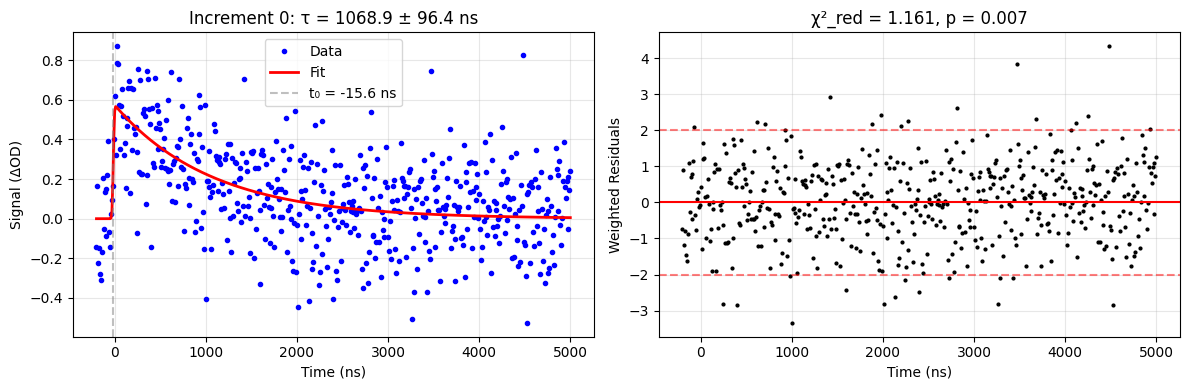


Processing increment 1:
  Pump FWHM = 14.20 ns -> σ = 6.03 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 11.12 ns
  Measurement error (σ_noise) = 2.5099e-01
  Initial guesses: A=1.6458, τ=320.69 ns, t0=20.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 1.3673 ± 0.0606
    τ  = 721.09 ± 45.09 ns
    t0 = -12.60 ± 3.74 ns

  Goodness of fit:
    χ² = 385.97
    χ²_red = 0.7451 (ideal: ~1)
    p-value = 1.0000 (ideal: 0.05-0.95)
    R² = 0.672546


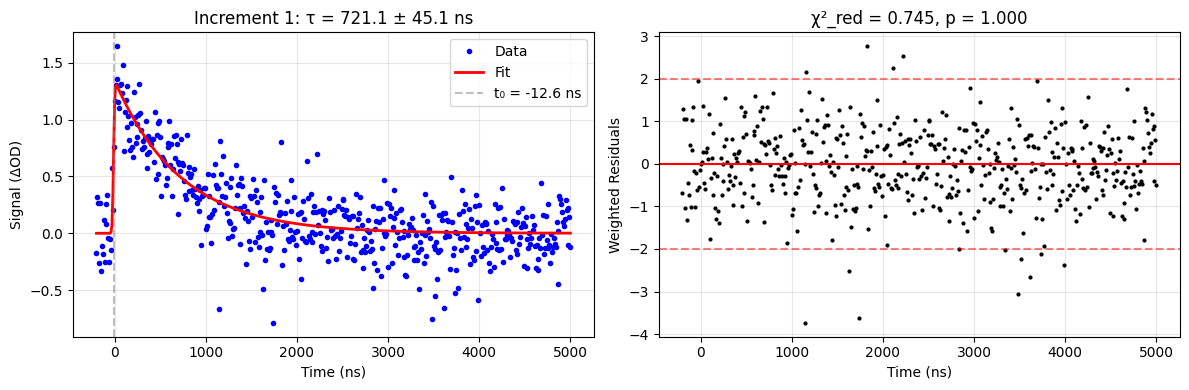


Processing increment 10:
  Pump FWHM = 88.00 ns -> σ = 37.37 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 38.52 ns
  Measurement error (σ_noise) = 2.7458e-01
  Initial guesses: A=8.5770, τ=303.01 ns, t0=70.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 9.3418 ± 0.0640
    τ  = 848.92 ± 8.18 ns
    t0 = 28.67 ± 1.18 ns

  Goodness of fit:
    χ² = 578.82
    χ²_red = 1.1174 (ideal: ~1)
    p-value = 0.0328 (ideal: 0.05-0.95)
    R² = 0.981589

Processing increment 11:
  Pump FWHM = 96.20 ns -> σ = 40.85 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 41.90 ns
  Measurement error (σ_noise) = 3.1850e-01
  Initial guesses: A=9.3410, τ=346.45 ns, t0=110.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 9.8288 ± 0.0728
    τ  = 888.54 ± 9.26 ns
    t0 = 31.40 ± 1.36 ns

  Goodness of fit:
    χ² = 426.62
    χ²_red = 0.8236 (ideal: ~1)
    p-value = 0.9987 (ideal: 0.05-0.95)
    R² = 0.983739

Processing increment 12:
  Pump FWHM = 104.40 ns -> σ = 44.3

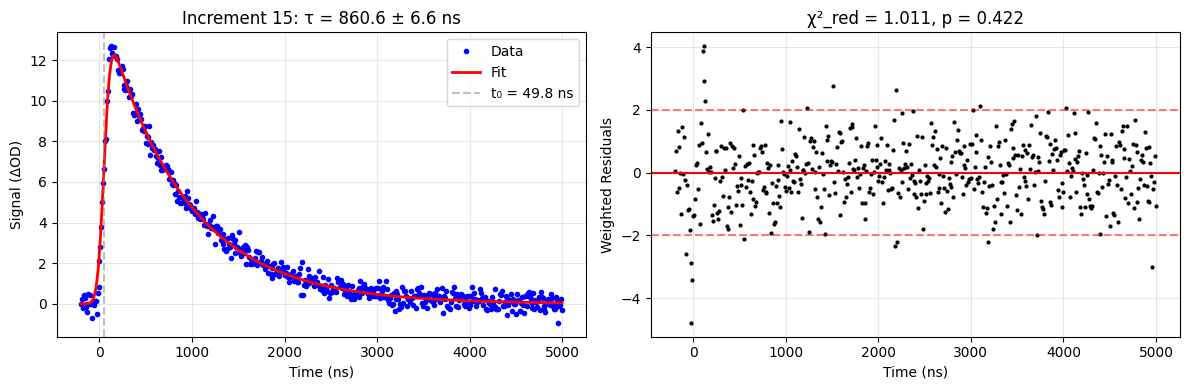


Processing increment 2:
  Pump FWHM = 22.40 ns -> σ = 9.51 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 13.33 ns
  Measurement error (σ_noise) = 2.2541e-01
  Initial guesses: A=2.3911, τ=348.87 ns, t0=120.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 2.1416 ± 0.0477
    τ  = 937.13 ± 29.46 ns
    t0 = -6.92 ± 2.35 ns

  Goodness of fit:
    χ² = 521.93
    χ²_red = 1.0076 (ideal: ~1)
    p-value = 0.4434 (ideal: 0.05-0.95)
    R² = 0.830697

Processing increment 3:
  Pump FWHM = 30.60 ns -> σ = 12.99 ns
  Probe FWHM = 22.0 ns -> σ = 9.34 ns
  Total σ_IRF = 16.00 ns
  Measurement error (σ_noise) = 2.0169e-01
  Initial guesses: A=3.1684, τ=267.92 ns, t0=50.00 ns

  ✅ Fit successful!
  Fitted parameters:
    A  = 3.0880 ± 0.0458
    τ  = 823.71 ± 17.25 ns
    t0 = -0.20 ± 1.61 ns

  Goodness of fit:
    χ² = 703.51
    χ²_red = 1.3581 (ideal: ~1)
    p-value = 0.0000 (ideal: 0.05-0.95)
    R² = 0.903859

Processing increment 4:
  Pump FWHM = 38.80 ns -> σ = 16.48 n

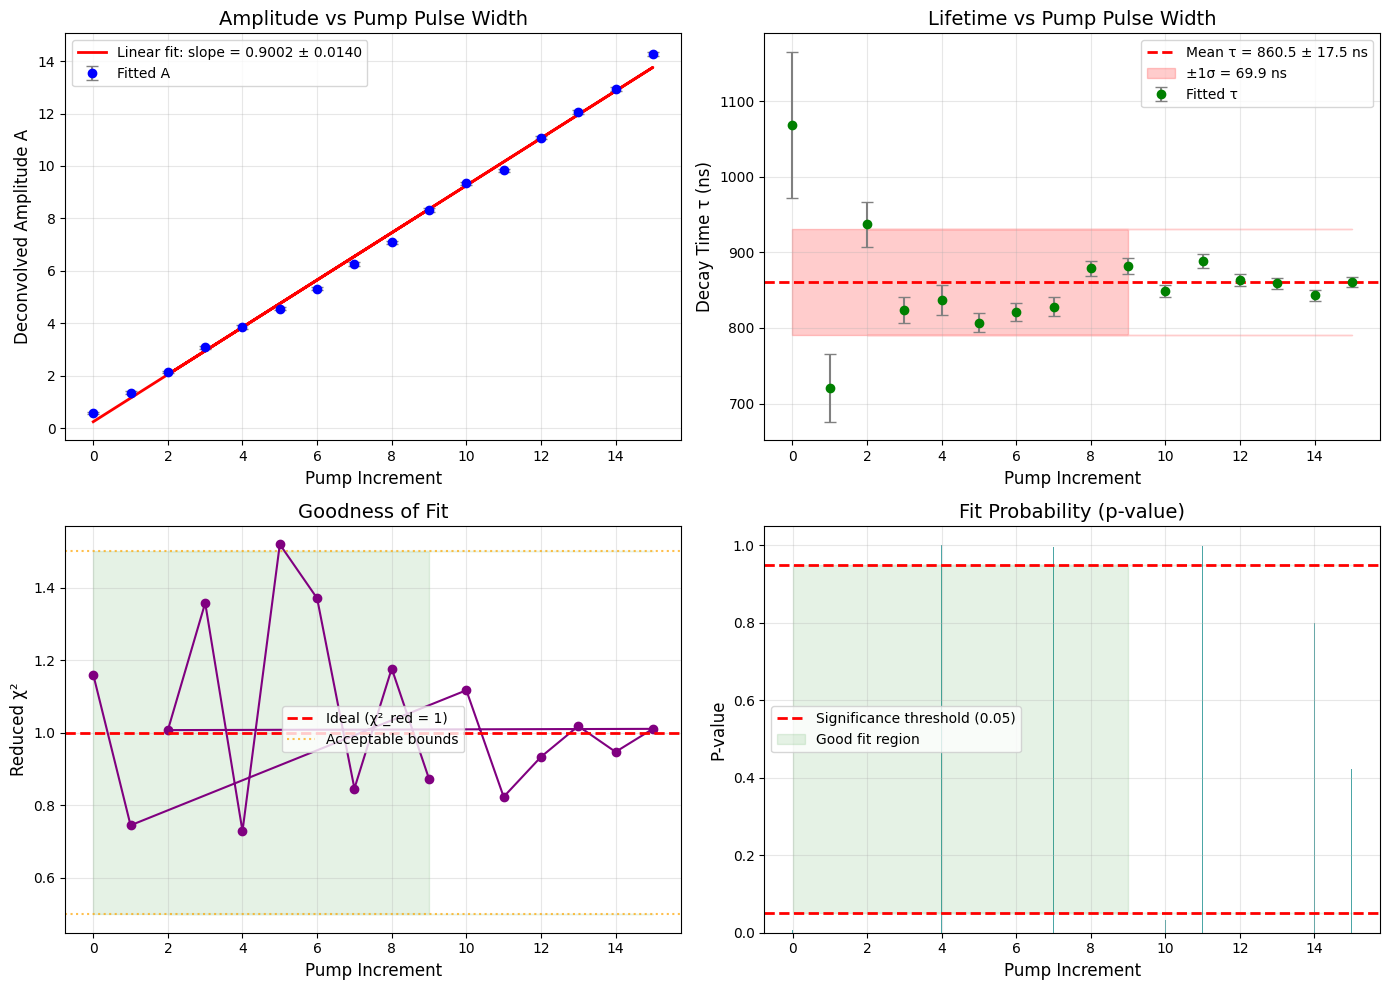


QUALITY ASSESSMENT
✅ Good: χ²_red is in ideal range (0.5-1.5)
✅ Good: Lifetime is consistent across pump widths (<10% variation)

Final Lifetime Result: τ = 855.6 ± 2.6 ns
(Weighted average of 16 measurements)


In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit
from scipy.special import erfc
from scipy import stats

# ── Constants and Parameters ─────────────────────────────────────────────────────────────
NS_PER_INCREMENT = (129 - 6) / 15   # ~8.2 ns per pump increment (FWHM)
FWHM_TO_SIGMA = 1 / 2.355           # Conversion factor: sigma = FWHM / 2.355

# Laser pulse parameters (all in FWHM, ns)
BASE_PUMP_FWHM = 6.0                # Base pump pulse width at increment 0 (ns)
PROBE_FWHM = 22.0                   # Probe pulse width FWHM (ns)

def analytical_model(t, A, tau, t0, sigma_irf):
    """
    Exponentially Modified Gaussian (EMG) for kinetics.
    Exact analytical solution for exponential decay convolved with Gaussian IRF.

    Parameters:
    -----------
    t : array_like
        Time points (ns)
    A : float
        Amplitude (initial excited state population)
    tau : float
        Decay time constant (ns)
    t0 : float
        Time zero (ns)
    sigma_irf : float
        IRF standard deviation (ns, NOT FWHM!)

    Returns:
    --------
    array_like : Convolved signal
    """
    # Numerical safeguards
    tau = max(tau, 1e-6)        # Prevent division by zero
    sigma_irf = max(sigma_irf, 1e-6)

    # Pre-compute constants for efficiency
    sigma2 = sigma_irf ** 2
    tau2 = tau ** 2

    # EMG formula
    term1 = sigma2 / (2 * tau2) - (t - t0) / tau
    arg = (sigma2 / tau - (t - t0)) / (np.sqrt(2) * sigma_irf)

    return (A / 2) * np.exp(term1) * erfc(arg)

def calculate_chi_square(y_obs, y_pred, y_err, n_params):
    """
    Calculate reduced chi-square statistic for goodness of fit.

    Parameters:
    -----------
    y_obs : array_like
        Observed data
    y_pred : array_like
        Predicted/fitted data
    y_err : array_like
        Measurement errors (standard deviations)
    n_params : int
        Number of fitted parameters (A, tau, t0 = 3)

    Returns:
    --------
    chi_sq : float
        Chi-square value
    chi_sq_red : float
        Reduced chi-square (should be ~1 for good fit)
    p_value : float
        P-value for goodness of fit (0.05-0.95 typically good)
    """
    residuals = y_obs - y_pred
    chi_sq = np.sum((residuals / y_err) ** 2)
    dof = len(y_obs) - n_params
    chi_sq_red = chi_sq / dof if dof > 0 else np.inf

    # Calculate p-value from chi-square distribution
    p_value = 1 - stats.chi2.cdf(chi_sq, dof) if dof > 0 else 0

    return chi_sq, chi_sq_red, p_value

def estimate_measurement_error(signal, window_size=5):
    """
    Estimate measurement error from the pre-trigger baseline noise.

    Parameters:
    -----------
    signal : array_like
        Signal trace
    window_size : int
        Number of points to use for noise estimation

    Returns:
    --------
    noise_std : float
        Estimated standard deviation of measurement noise
    """
    # Use the first 'window_size' points (pre-trigger) to estimate noise
    noise_region = signal[:min(window_size, len(signal))]
    return max(np.std(noise_region), 1e-6)  # Prevent zero error

def get_initial_guesses(t, signal, sigma_irf):
    """
    Generate intelligent initial guesses for EMG fitting.

    Parameters:
    -----------
    t : array_like
        Time points
    signal : array_like
        Signal values
    sigma_irf : float
        IRF standard deviation

    Returns:
    --------
    tuple : (A_guess, tau_guess, t0_guess)
    """
    # Find peak position
    peak_idx = np.argmax(signal)
    t0_guess = t[peak_idx]

    # Amplitude guess: observed peak * approximate correction factor
    # For tau >> sigma, correction factor ~ exp(sigma²/(2τ²))
    tau_guess_initial = 1000.0  # Based on prior knowledge (~1009 ns)
    correction = np.exp(sigma_irf**2 / (2 * tau_guess_initial**2))
    A_guess = signal[peak_idx] * correction

    # Estimate tau from the tail (after ~3 sigma from peak)
    tail_start_idx = np.searchsorted(t, t0_guess + 3 * sigma_irf)
    if tail_start_idx < len(t) and tail_start_idx + 5 < len(t):
        tail_t = t[tail_start_idx:]
        tail_signal = signal[tail_start_idx:]

        # Fit exponential to tail in log space
        log_signal = np.log(np.maximum(tail_signal, 1e-10))
        if len(tail_t) > 3:
            # Linear fit: log(y) = log(A) - t/tau
            coeffs = np.polyfit(tail_t - tail_t[0], log_signal, 1)
            tau_guess = -1 / coeffs[0] if coeffs[0] < 0 else tau_guess_initial
        else:
            tau_guess = tau_guess_initial
    else:
        tau_guess = tau_guess_initial

    return A_guess, tau_guess, t0_guess

# ── Main Processing Loop ─────────────────────────────────────────────────────────────────
increment_array = []
A_array = []
tau_array = []
A_err_array = []
tau_err_array = []
chi_sq_red_array = []
p_value_array = []

# Assuming 'filelist' and 'pathTRAS' are defined in your environment
for file in sorted(filelist):
    if not (file.endswith(".csv") and "TA" in file):
        continue

    # Extract pump increment from filename
    match = re.search(r"pump\s*(\d+)", file, re.IGNORECASE)
    if not match:
        print(f"Skipping {file}: cannot parse pump increment")
        continue

    increment = int(match.group(1))

    # Read data
    df = pd.read_csv(
        os.path.join(pathTRAS, file),
        sep=";",
        header=None,
        names=["time", "signal"]
    )
    df = df.iloc[1:].reset_index(drop=True).astype(float)

    # Background subtraction using pre-trigger region (t < -10 ns)
    bg_mask = df["time"] < -10
    if bg_mask.sum() > 0:
        bg_mean = df[bg_mask]["signal"].mean()
    else:
        bg_mean = df["signal"].iloc[:10].mean()

    # Correct signal and keep region of interest (include some pre-trigger)
    df_spike = df[df["time"] >= -200].copy()
    df_spike["signal_corr"] = df_spike["signal"] - bg_mean

    time_data = df_spike["time"].to_numpy()
    signal_data = df_spike["signal_corr"].to_numpy()

    # Estimate measurement error from pre-trigger region
    pre_trigger_mask = time_data < -10
    if pre_trigger_mask.sum() > 5:
        measurement_error = np.std(signal_data[pre_trigger_mask])
    else:
        measurement_error = estimate_measurement_error(signal_data)
    measurement_error = max(measurement_error, 1e-6)

    # Calculate IRF width (convert FWHM to sigma)
    pump_fwhm = BASE_PUMP_FWHM + increment * NS_PER_INCREMENT
    pump_sigma = pump_fwhm * FWHM_TO_SIGMA
    probe_sigma = PROBE_FWHM * FWHM_TO_SIGMA
    sigma_irf = np.sqrt(pump_sigma**2 + probe_sigma**2)

    print(f"\n{'='*60}")
    print(f"Processing increment {increment}:")
    print(f"  Pump FWHM = {pump_fwhm:.2f} ns -> σ = {pump_sigma:.2f} ns")
    print(f"  Probe FWHM = {PROBE_FWHM:.1f} ns -> σ = {probe_sigma:.2f} ns")
    print(f"  Total σ_IRF = {sigma_irf:.2f} ns")
    print(f"  Measurement error (σ_noise) = {measurement_error:.4e}")

    # Define model with fixed sigma_irf
    def model_fixed_irf(t, A, tau, t0):
        return analytical_model(t, A, tau, t0, sigma_irf)

    # Get initial guesses
    A_guess, tau_guess, t0_guess = get_initial_guesses(time_data, signal_data, sigma_irf)
    print(f"  Initial guesses: A={A_guess:.4f}, τ={tau_guess:.2f} ns, t0={t0_guess:.2f} ns")

    try:
        # Perform fit with bounds
        popt, pcov = curve_fit(
            model_fixed_irf,
            time_data,
            signal_data,
            p0=[A_guess, tau_guess, t0_guess],
            bounds=([0, 10, time_data[0]], [np.inf, 5000, time_data[-1]]),
            maxfev=10000,
            sigma=measurement_error * np.ones_like(signal_data),
            absolute_sigma=True
        )

        # Calculate parameter errors
        perr = np.sqrt(np.diag(pcov))
        A_fit, tau_fit, t0_fit = popt
        A_err, tau_err, t0_err = perr

        # Calculate fit and chi-square statistics
        fitted_signal = model_fixed_irf(time_data, A_fit, tau_fit, t0_fit)
        chi_sq, chi_sq_red, p_value = calculate_chi_square(
            signal_data, fitted_signal,
            measurement_error * np.ones_like(signal_data),
            n_params=3
        )

        # Calculate R-squared
        ss_res = np.sum((signal_data - fitted_signal)**2)
        ss_tot = np.sum((signal_data - np.mean(signal_data))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

        # Print results
        print(f"\n  ✅ Fit successful!")
        print(f"  Fitted parameters:")
        print(f"    A  = {A_fit:.4f} ± {A_err:.4f}")
        print(f"    τ  = {tau_fit:.2f} ± {tau_err:.2f} ns")
        print(f"    t0 = {t0_fit:.2f} ± {t0_err:.2f} ns")
        print(f"\n  Goodness of fit:")
        print(f"    χ² = {chi_sq:.2f}")
        print(f"    χ²_red = {chi_sq_red:.4f} (ideal: ~1)")
        print(f"    p-value = {p_value:.4f} (ideal: 0.05-0.95)")
        print(f"    R² = {r_squared:.6f}")

        # Store results
        increment_array.append(increment)
        A_array.append(A_fit)
        tau_array.append(tau_fit)
        A_err_array.append(A_err)
        tau_err_array.append(tau_err)
        chi_sq_red_array.append(chi_sq_red)
        p_value_array.append(p_value)

        # Optional: Plot individual fit for inspection
        if abs(increment) <= 1 or increment == max([int(re.search(r"pump\s*(\d+)", f, re.IGNORECASE).group(1))
                                                     for f in filelist if re.search(r"pump\s*(\d+)", f)]):
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

            # Main fit plot
            ax1.plot(time_data, signal_data, 'bo', markersize=3, label='Data')
            ax1.plot(time_data, fitted_signal, 'r-', linewidth=2, label='Fit')
            ax1.axvline(t0_fit, color='gray', linestyle='--', alpha=0.5, label=f't₀ = {t0_fit:.1f} ns')
            ax1.set_xlabel('Time (ns)')
            ax1.set_ylabel('Signal (ΔOD)')
            ax1.set_title(f'Increment {increment}: τ = {tau_fit:.1f} ± {tau_err:.1f} ns')
            ax1.legend()
            ax1.grid(True, alpha=0.3)

            # Residuals plot
            residuals = signal_data - fitted_signal
            ax2.plot(time_data, residuals / measurement_error, 'ko', markersize=2)
            ax2.axhline(0, color='r', linestyle='-')
            ax2.axhline(2, color='r', linestyle='--', alpha=0.5)
            ax2.axhline(-2, color='r', linestyle='--', alpha=0.5)
            ax2.set_xlabel('Time (ns)')
            ax2.set_ylabel('Weighted Residuals')
            ax2.set_title(f'χ²_red = {chi_sq_red:.3f}, p = {p_value:.3f}')
            ax2.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

    except (RuntimeError, ValueError) as e:
        print(f"\n  ❌ Fit failed for increment {increment}: {e}")
        continue

# ── Convert to arrays for analysis ──────────────────────────────────────────────────────
increment_array = np.array(increment_array)
A_array = np.array(A_array)
tau_array = np.array(tau_array)
A_err_array = np.array(A_err_array)
tau_err_array = np.array(tau_err_array)
chi_sq_red_array = np.array(chi_sq_red_array)
p_value_array = np.array(p_value_array)

# ── Statistical Analysis of Results ─────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")

# Amplitude analysis
coeff_A, cov_A = np.polyfit(increment_array, A_array, 1, cov=True)
slope_A = coeff_A[0]
intercept_A = coeff_A[1]
slope_A_err = np.sqrt(cov_A[0, 0])
intercept_A_err = np.sqrt(cov_A[1, 1])

# Lifetime analysis
tau_mean = np.mean(tau_array)
tau_std = np.std(tau_array)
tau_sem = tau_std / np.sqrt(len(tau_array))
tau_weighted_mean = np.average(tau_array, weights=1/tau_err_array**2)
tau_weighted_std = np.sqrt(1 / np.sum(1/tau_err_array**2))

# Chi-square statistics
mean_chi_sq_red = np.mean(chi_sq_red_array)
good_fits = np.sum((chi_sq_red_array > 0.5) & (chi_sq_red_array < 1.5))

print(f"\nAmplitude Analysis:")
print(f"  Slope: {slope_A:.4f} ± {slope_A_err:.4f}")
print(f"  Intercept: {intercept_A:.4f} ± {intercept_A_err:.4f}")

print(f"\nLifetime Analysis:")
print(f"  Mean τ: {tau_mean:.2f} ± {tau_sem:.2f} ns")
print(f"  Std Dev: {tau_std:.2f} ns")
print(f"  Weighted mean τ: {tau_weighted_mean:.2f} ± {tau_weighted_std:.2f} ns")
print(f"  Range: {tau_array.min():.2f} - {tau_array.max():.2f} ns")

print(f"\nGoodness of Fit Summary:")
print(f"  Mean χ²_red: {mean_chi_sq_red:.4f}")
print(f"  Good fits (0.5 < χ²_red < 1.5): {good_fits}/{len(chi_sq_red_array)} ({100*good_fits/len(chi_sq_red_array):.1f}%)")

# ── Create Final Publication-Quality Plot ───────────────────────────────────────────────
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Amplitude vs Pump Increment
ax1.errorbar(increment_array, A_array, yerr=A_err_array,
             fmt='o', capsize=4, markersize=6, color='blue',
             label='Fitted A', ecolor='gray')
ax1.plot(increment_array, np.polyval(coeff_A, increment_array),
         'r-', linewidth=2,
         label=f'Linear fit: slope = {slope_A:.4f} ± {slope_A_err:.4f}')
ax1.set_xlabel("Pump Increment", fontsize=12)
ax1.set_ylabel("Deconvolved Amplitude A", fontsize=12)
ax1.set_title("Amplitude vs Pump Pulse Width", fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Decay Time vs Pump Increment
ax2.errorbar(increment_array, tau_array, yerr=tau_err_array,
             fmt='o', capsize=4, markersize=6, color='green',
             label='Fitted τ', ecolor='gray')
ax2.axhline(tau_mean, color='red', linestyle='--', linewidth=2,
            label=f'Mean τ = {tau_mean:.1f} ± {tau_sem:.1f} ns')
ax2.fill_between(increment_array, tau_mean - tau_std, tau_mean + tau_std,
                  alpha=0.2, color='red', label=f'±1σ = {tau_std:.1f} ns')
ax2.set_xlabel("Pump Increment", fontsize=12)
ax2.set_ylabel("Decay Time τ (ns)", fontsize=12)
ax2.set_title("Lifetime vs Pump Pulse Width", fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Reduced Chi-Square Values
ax3.plot(increment_array, chi_sq_red_array, 'o-', color='purple', markersize=6)
ax3.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Ideal (χ²_red = 1)')
ax3.axhline(0.5, color='orange', linestyle=':', alpha=0.7, label='Acceptable bounds')
ax3.axhline(1.5, color='orange', linestyle=':', alpha=0.7)
ax3.fill_between(increment_array, 0.5, 1.5, alpha=0.1, color='green')
ax3.set_xlabel("Pump Increment", fontsize=12)
ax3.set_ylabel("Reduced χ²", fontsize=12)
ax3.set_title("Goodness of Fit", fontsize=14)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: P-values
ax4.bar(increment_array, p_value_array, width=0.015, color='teal', alpha=0.7)
ax4.axhline(0.05, color='red', linestyle='--', linewidth=2, label='Significance threshold (0.05)')
ax4.axhline(0.95, color='red', linestyle='--', linewidth=2)
ax4.fill_between(increment_array, 0.05, 0.95, alpha=0.1, color='green', label='Good fit region')
ax4.set_xlabel("Pump Increment", fontsize=12)
ax4.set_ylabel("P-value", fontsize=12)
ax4.set_title("Fit Probability (p-value)", fontsize=14)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("TRAS_Deconvolution_Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Summary Statistics Output ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("QUALITY ASSESSMENT")
print(f"{'='*60}")

if mean_chi_sq_red < 0.5:
    print("⚠️  Warning: χ²_red < 0.5 - Overestimated measurement errors or overfitting")
elif mean_chi_sq_red > 1.5:
    print("⚠️  Warning: χ²_red > 1.5 - Underestimated measurement errors or poor model")
else:
    print("✅ Good: χ²_red is in ideal range (0.5-1.5)")

if np.std(tau_array) / np.mean(tau_array) < 0.05:
    print("✅ Excellent: Lifetime is highly consistent across pump widths (<5% variation)")
elif np.std(tau_array) / np.mean(tau_array) < 0.10:
    print("✅ Good: Lifetime is consistent across pump widths (<10% variation)")
else:
    print("⚠️  Warning: Lifetime shows significant variation across pump widths")

print(f"\nFinal Lifetime Result: τ = {tau_weighted_mean:.1f} ± {tau_weighted_std:.1f} ns")
print(f"(Weighted average of {len(tau_array)} measurements)")